In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [ ]:
file_name = "1) iris.csv"
df = pd.read_csv(file_name)

df_binary = df[df['species'].isin(['versicolor', 'virginica'])].copy()
df_binary['label'] = df_binary['species'].map({'versicolor': 0, 'virginica': 1})

X = df_binary[['petal_length', 'petal_width']]
y = df_binary['label']

print("Class Distribution After Binary Filtering:")
print(df_binary['species'].value_counts())

Class Distribution After Binary Filtering:
species
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Matrix Shape: {X_train_scaled.shape}")
print(f"Testing Matrix Shape: {X_test_scaled.shape}")

Training Matrix Shape: (70, 2)
Testing Matrix Shape: (30, 2)


In [ ]:
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

def evaluate_model(model, X_scaled, y_true):
    preds = model.predict(X_scaled)
    probs = model.predict_proba(X_scaled)[:, 1]
    return {
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1-Score': f1_score(y_true, preds),
        'AUC': roc_auc_score(y_true, probs)
    }

metrics_linear = evaluate_model(svm_linear, X_test_scaled, y_test)
metrics_rbf = evaluate_model(svm_rbf, X_test_scaled, y_test)

comparison_df = pd.DataFrame({'Linear Kernel': metrics_linear, 'RBF Kernel': metrics_rbf})
print("Performance Comparison Matrix on Test Dataset:\n")
print(comparison_df.round(4))

Performance Comparison Matrix on Test Dataset:

           Linear Kernel  RBF Kernel
Accuracy          0.8667      0.9000
Precision         0.9231      0.9286
Recall            0.8000      0.8667
F1-Score          0.8571      0.8966
AUC               0.9867      0.9867


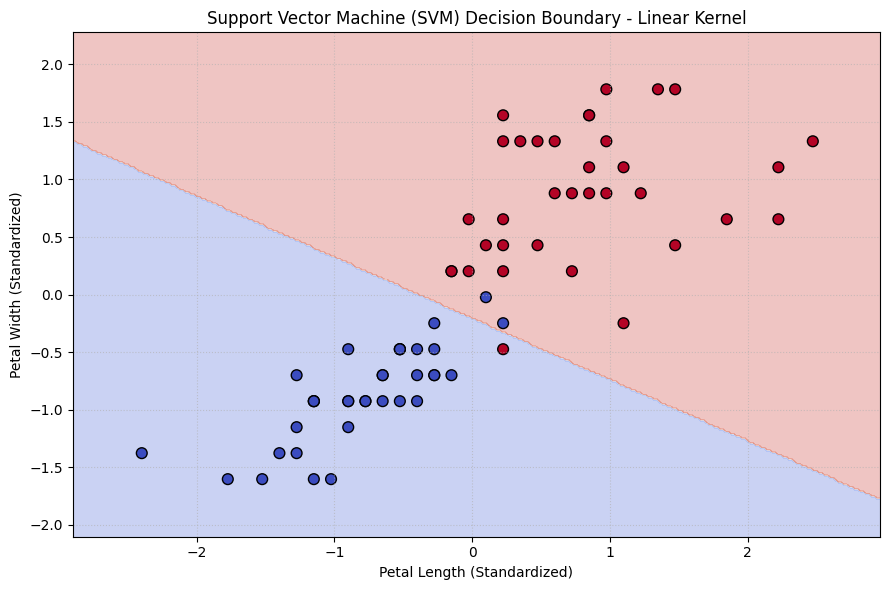

In [ ]:
h = 0.02
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_linear.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='black', s=60)
plt.title('Support Vector Machine (SVM) Decision Boundary - Linear Kernel')
plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('svm_linear_boundary_corrected.png')
plt.show()

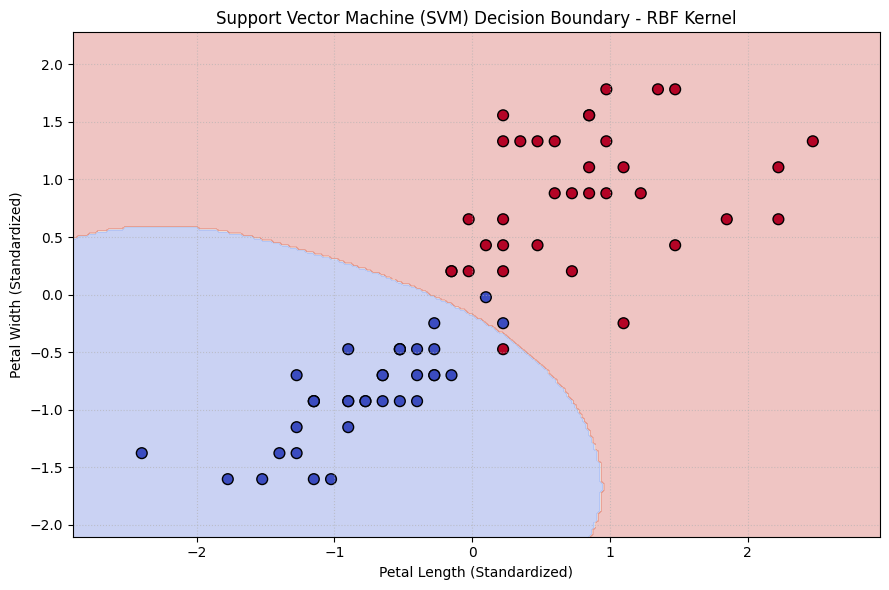

In [ ]:
Z_rbf = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='black', s=60)
plt.title('Support Vector Machine (SVM) Decision Boundary - RBF Kernel')
plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('svm_rbf_boundary_corrected.png')
plt.show()